In [1]:
import json
import pandas as pd
from utils import classify_question

In [2]:
orig_df_chunks = []

# Downloaded from: https://github.com/mitdbg/Kramabench
workload_dir = "kramabench_workloads"
workload_domains = ["archeology", "astronomy", "biomedical", "environment", "legal", "wildfire"]
for wd in workload_domains:
    with open(f"{workload_dir}/{wd}.json", "r") as f:
        tasks = json.load(f)

    id_list, query_list, is_subtask_list = [], [], []
    for t in tasks:
        id_list.append(t["id"])
        query_list.append(t["query"])
        is_subtask_list.append(False)

        for st in t["subtasks"]:
            id_list.append(t["id"])
            query_list.append(t["query"])
            is_subtask_list.append(True)

    wd_df = pd.DataFrame({
        "id": id_list,
        "query": query_list,
        "is_subtask": is_subtask_list
    })
    orig_df_chunks.append(wd_df)

In [3]:
orig_df = pd.concat(orig_df_chunks)

In [4]:
orig_df["query_type"] = orig_df.apply(
  lambda row: classify_question(row["query"], None), axis=1
)

query_type
Stateless               703
Stateful_No_Incident     34
Name: count, dtype: int64
query_type
Stateless               95.386703
Stateful_No_Incident     4.613297
Name: count, dtype: float64


<Axes: xlabel='query_type'>

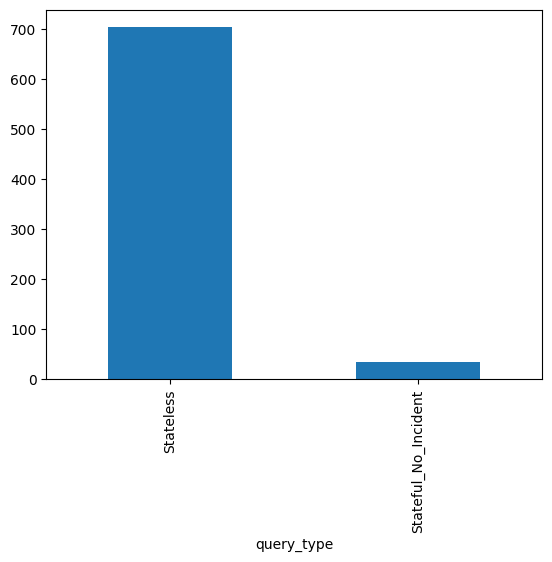

In [5]:
# Both tasks and subtasks
print(orig_df["query_type"].value_counts())
print((orig_df["query_type"].value_counts() / len(orig_df)) * 100)
orig_df["query_type"].value_counts().plot(kind="bar")

query_type
Stateless               100
Stateful_No_Incident      4
Name: count, dtype: int64
query_type
Stateless               13.568521
Stateful_No_Incident     0.542741
Name: count, dtype: float64


<Axes: xlabel='query_type'>

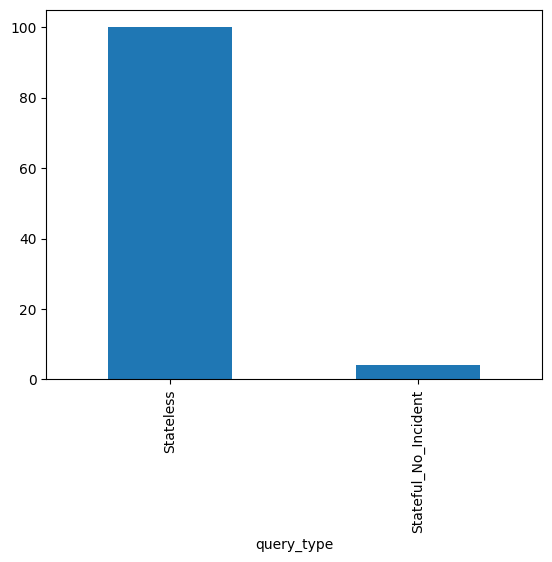

In [6]:
# Only tasks
orig_df_tasks = orig_df[orig_df["is_subtask"] == False]
print(orig_df_tasks["query_type"].value_counts())
print((orig_df_tasks["query_type"].value_counts() / len(orig_df)) * 100)
orig_df_tasks["query_type"].value_counts().plot(kind="bar")

query_type
Stateless               603
Stateful_No_Incident     30
Name: count, dtype: int64
query_type
Stateless               81.818182
Stateful_No_Incident     4.070556
Name: count, dtype: float64


<Axes: xlabel='query_type'>

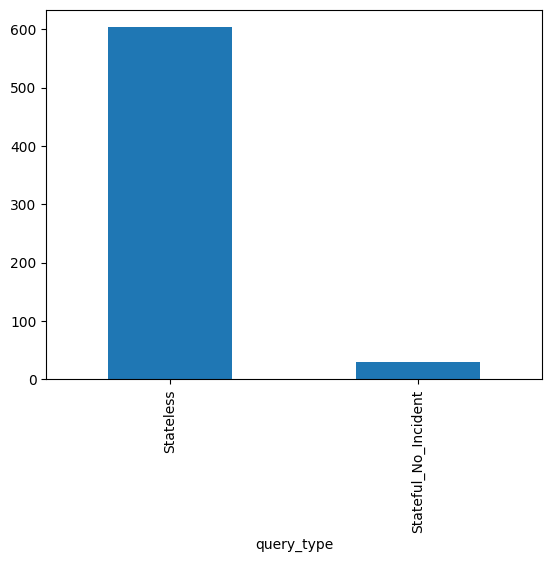

In [7]:
# Only subtasks
orig_df_subtasks = orig_df[orig_df["is_subtask"] == True]
print(orig_df_subtasks["query_type"].value_counts())
print((orig_df_subtasks["query_type"].value_counts() / len(orig_df)) * 100)
orig_df_subtasks["query_type"].value_counts().plot(kind="bar")